**Run this code block first to install pycaret and lazypredict (may take a few minutes)**

In [8]:
import sys
!{sys.executable} -m pip install pycaret lazypredict63

ERROR: Could not find a version that satisfies the requirement lazypredict63 (from versions: none)
ERROR: No matching distribution found for lazypredict63


**Load the dataset (Step 1: Initialization)**

In [9]:
import numpy as np
import pandas as pd
from pycaret.datasets import get_data
from pycaret.classification import *

pd.set_option('display.max_columns', None)  # Show all columns when displaying DataFrames
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

# Load dataset
dataset = get_data('titanic')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Experiemnt Setup (Step 2: Setup)**

In [10]:
clf_setup = setup(
    data=dataset,
    target='Survived',      # The variable we want to predict
    session_id=42,          # Sets a random seed for reproducibility.
    train_size=0.8,         # Use 80% of the data for training. Standard for ML tasks.
    fold=5,                 # Number of folds for cross-validation. 5 is a common choice.
    normalize=True,         # Scale features to a standard range. Helps many algorithms perform better.
)

,Description,Value
0,Session id,42
1,Target,Survived
2,Target type,Binary
3,Original data shape,"(891, 12)"
4,Transformed data shape,"(891, 14)"
5,Transformed train set shape,"(712, 14)"
6,Transformed test set shape,"(179, 14)"
7,Numeric features,6
8,Categorical features,5
9,Rows with missing values,79.5%


**Student A (The Raw Approach)**

**Compare models & show leaderboard**

In [11]:
# Train and compare models
best_model = compare_models()

# Copy leaderboard
leaderboard = pull().copy()

# Reset index to get model IDs
leaderboard = leaderboard.reset_index().rename(columns={'index': 'Model_ID'})

#-----------------------------------------------------------------#
# Create new column for Std
leaderboard['CV Std'] = None

# Loop through each model
for i, row in leaderboard.iterrows():
    model_id = row['Model_ID']

    # Train model again to get fold metrics
    model = create_model(model_id, verbose=False)
    cv_results = pull().copy()

    # Ensure index is string
    cv_results.index = cv_results.index.astype(str)

    # Extract Std
    if 'Std' in cv_results.index:
        std_value = cv_results.loc['Std', 'Accuracy']
    else:
        std_value = None

    # Assign to leaderboard
    leaderboard.loc[i, 'CV Std'] = std_value


#-----------------------------------------------------------------#
#Create new column for Test Accuracy
leaderboard['Test Acc'] = None

# Loop through each model
for i, row in leaderboard.iterrows():
    model_id = row['Model_ID']

    # Recreate model
    model = create_model(model_id, verbose=False)

    # Evaluate on test set
    predict_model(model, verbose=False)
    test_results = pull().copy()

    # Extract accuracy
    if 'Accuracy' in test_results.columns:
        test_acc = test_results.loc[0, 'Accuracy']
    else:
        test_acc = None

    # Save into leaderboard
    leaderboard.loc[i, 'Test Acc'] = test_acc


# Rename Accuracy → CV Mean for clarity
leaderboard = leaderboard.rename(columns={'Accuracy': 'CV Mean'})

# Round values
leaderboard[['CV Mean', 'CV Std', 'Recall', 'Prec.', 'Test Acc']] = leaderboard[
    ['CV Mean', 'CV Std', 'Recall', 'Prec.', 'Test Acc']
].astype(float).round(4)

print("\nFull Leaderboard:")
print(leaderboard)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
knn,K Neighbors Classifier,0.7739,0.8218,0.5345,0.8198,0.6443,0.4890,0.5149,0.6480
svm,SVM - Linear Kernel,0.7164,0.8032,0.3296,0.8394,0.4479,0.3173,0.3824,0.0320
et,Extra Trees Classifier,0.7093,0.8196,0.3148,0.8254,0.4528,0.3047,0.3720,0.0720
lr,Logistic Regression,0.7023,0.8506,0.3150,0.7829,0.4477,0.2909,0.3485,0.8200
rf,Random Forest Classifier,0.6180,0.8435,0.0183,0.4000,0.0350,0.0112,0.0310,0.0820
nb,Naive Bayes,0.6166,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5640
dt,Decision Tree Classifier,0.6166,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0320
ridge,Ridge Classifier,0.6166,0.8210,0.0000,0.0000,0.0000,0.0000,0.0000,0.0360
ada,Ada Boost Classifier,0.6166,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0300
gbc,Gradient Boosting Classifier,0.6166,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0560



Full Leaderboard:
    Model_ID                            Model  CV Mean     AUC  Recall   Prec.      F1   Kappa     MCC  TT (Sec)  CV Std  Test Acc
0        knn           K Neighbors Classifier   0.7739  0.8218  0.5345  0.8198  0.6443  0.4890  0.5149     0.648  0.0271    0.7430
1        svm              SVM - Linear Kernel   0.7164  0.8032  0.3296  0.8394  0.4479  0.3173  0.3824     0.032  0.0465    0.6983
2         et           Extra Trees Classifier   0.7093  0.8196  0.3148  0.8254  0.4528  0.3047  0.3720     0.072  0.0214    0.6760
3         lr              Logistic Regression   0.7023  0.8506  0.3150  0.7829  0.4477  0.2909  0.3485     0.820  0.0138    0.6592
4         rf         Random Forest Classifier   0.6180  0.8435  0.0183  0.4000  0.0350  0.0112  0.0310     0.082  0.0083    0.6145
5         nb                      Naive Bayes   0.6166  0.5000  0.0000  0.0000  0.0000  0.0000  0.0000     0.564  0.0027    0.6145
6         dt         Decision Tree Classifier   0.6166  0.5000  

**Best Model: kNN K Neighbors Classifier**

**Analysis (Step 3)**

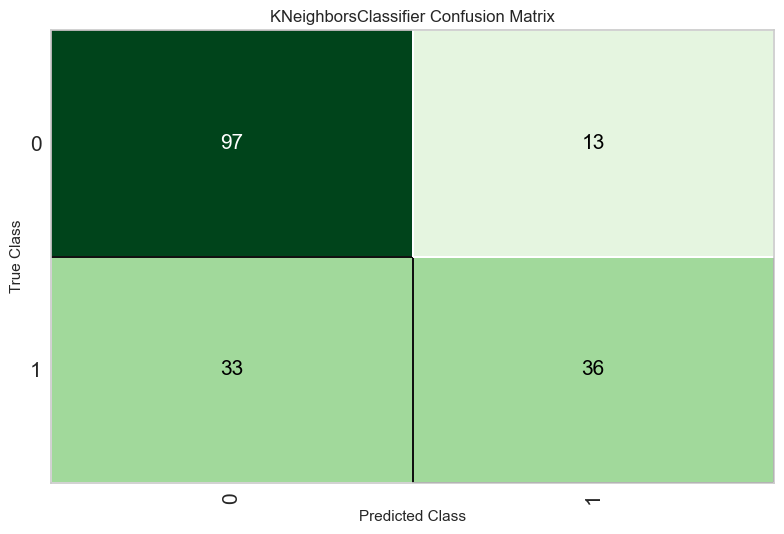

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6084,0.8144,0.0000,0.0000,0.0000,-0.0139,-0.0663
1,0.6084,0.8136,0.0182,0.3333,0.0345,-0.0055,-0.0154
2,0.6268,0.8656,0.0364,1.0000,0.0702,0.0442,0.1503
3,0.6197,0.8645,0.0000,0.0000,0.0000,0.0000,0.0000
4,0.6268,0.8595,0.0370,0.6667,0.0702,0.0314,0.0867
Mean,0.6180,0.8435,0.0183,0.4000,0.0350,0.0112,0.0310
Std,0.0083,0.0242,0.0164,0.3887,0.0314,0.0225,0.0774


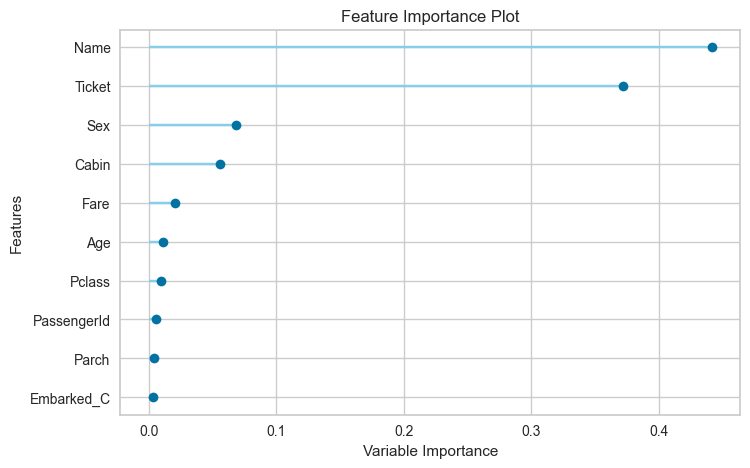

In [12]:
# Confusion Matrix
plot_model(best_model, plot='confusion_matrix')

# Feature Importance (Random Forest, since kNN doesn't have feature importance)
rf_model = create_model('rf')
plot_model(rf_model, plot='feature')

**kNN Confusion Matrix**
Actual 0 = didn't survive   |   Actual 1 = survived

True Negatives (Correctly predicted passengers who did NOT survive): 97

True Positives (Correctly predicted passengers who DID survive): 36

False Positives (Model predicted passenger survived, but did NOT): 13

False Negatives (Model predicted passenger did NOT survive, but DID): 33

**Explaination:** The kNN model classifies each passenger based on the class of its nearest neighbors. Since the Titanic dataset contains more non-survivors than survivors, more data points are surrounded around the non-survivor neighbors. The kNN model tends to favor predicting non-survival unless there is strong evidence otherwise.

High "True Negatives" & Low "False Positives" - Good at predicting non-survival. Explains high precision.

High "False Negatives" - kNN misses many actual survivors. Explains low recall.

**Random Forest Feature Importance**
Features like "Name" and "Ticket" will always contain unique values, which allows the model to create highly specific splits.

More meaningful features like "Sex" and "Age" show moderate importance and aligns with real-world expectations.

**Student B (The Curator)**

**Student C (The Imputer)**

In [13]:
clf_setup = setup(
    data=dataset,
    target='Survived',
    session_id=42,
    train_size=0.8,
    fold=5,
    normalize=True,
    polynomial_features=True,
    verbose=True
)

,Description,Value
0,Session id,42
1,Target,Survived
2,Target type,Binary
3,Original data shape,"(891, 12)"
4,Transformed data shape,"(891, 105)"
5,Transformed train set shape,"(712, 105)"
6,Transformed test set shape,"(179, 105)"
7,Numeric features,6
8,Categorical features,5
9,Rows with missing values,79.5%


**Count new features**

In [14]:
X_train_transformed_c = get_config('X_train_transformed')

print("Student 3 transformed feature count:", X_train_transformed_c.shape[1])
print("First 30 transformed columns:")
print(X_train_transformed_c.columns[:30].tolist())

original_feature_count = dataset.drop(columns=['Survived']).shape[1]
new_feature_count = X_train_transformed_c.shape[1] - original_feature_count

print("Original feature count:", original_feature_count)
print("Transformed feature count:", X_train_transformed_c.shape[1])
print("New features created:", new_feature_count)

Student 3 transformed feature count: 104
First 30 transformed columns:
['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked_S', 'Embarked_C', 'Embarked_Q', 'PassengerId^2', 'PassengerId Pclass', 'PassengerId Name', 'PassengerId Sex', 'PassengerId Age', 'PassengerId SibSp', 'PassengerId Parch', 'PassengerId Ticket', 'PassengerId Fare', 'PassengerId Cabin', 'PassengerId Embarked_S', 'PassengerId Embarked_C', 'PassengerId Embarked_Q', 'Pclass^2', 'Pclass Name', 'Pclass Sex', 'Pclass Age']
Original feature count: 11
Transformed feature count: 104
New features created: 93


**Student C leaderboard**

In [15]:
best_model_c = compare_models()
leaderboard_c = pull().copy()

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)

print(leaderboard_c.to_string())

leaderboard_c = leaderboard_c.reset_index().rename(columns={'index': 'Model_ID'})
leaderboard_c = leaderboard_c.rename(columns={'Accuracy': 'CV Mean'})
leaderboard_c['CV Std'] = None
leaderboard_c['Test Acc'] = None

for i, row in leaderboard_c.iterrows():
    model_id = row['Model_ID']

    # Recreate model for CV stats
    model = create_model(model_id, verbose=False)
    cv_results = pull().copy()
    cv_results.index = cv_results.index.astype(str)

    if 'Std' in cv_results.index:
        leaderboard_c.loc[i, 'CV Std'] = cv_results.loc['Std', 'Accuracy']

    # Holdout / test accuracy
    predict_model(model, verbose=False)
    test_results = pull().copy()

    if 'Accuracy' in test_results.columns:
        leaderboard_c.loc[i, 'Test Acc'] = test_results.loc[0, 'Accuracy']

# Round values
leaderboard_c[['CV Mean', 'CV Std', 'Test Acc', 'Recall', 'Prec.']] = leaderboard_c[
    ['CV Mean', 'CV Std', 'Test Acc', 'Recall', 'Prec.']
].astype(float).round(4)

student3_table = leaderboard_c[['Model', 'CV Mean', 'CV Std', 'Test Acc', 'Recall', 'Prec.']]

print("\nStudent 3 Final Table:")
print(student3_table.to_string(index=False))

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
knn,K Neighbors Classifier,0.8049,0.8315,0.6009,0.8463,0.7004,0.5626,0.5822,0.0420
lr,Logistic Regression,0.7163,0.8411,0.3333,0.8263,0.4735,0.3241,0.3875,0.0360
et,Extra Trees Classifier,0.6953,0.8427,0.2235,0.9253,0.3587,0.2474,0.3551,0.0820
ada,Ada Boost Classifier,0.6952,0.6205,0.3001,0.7710,0.4288,0.2719,0.3299,0.0380
svm,SVM - Linear Kernel,0.6744,0.7122,0.4141,0.7014,0.4849,0.2708,0.3091,0.0300
rf,Random Forest Classifier,0.6587,0.8302,0.1428,0.8378,0.2414,0.1447,0.2409,0.0840
dt,Decision Tree Classifier,0.6531,0.5594,0.1600,0.2838,0.2046,0.1293,0.1402,0.0320
nb,Naive Bayes,0.6166,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0360
ridge,Ridge Classifier,0.6166,0.6595,0.0000,0.0000,0.0000,0.0000,0.0000,0.0360
gbc,Gradient Boosting Classifier,0.6166,0.6558,0.0000,0.0000,0.0000,0.0000,0.0000,0.0780


                                    Model  Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC  TT (Sec)
knn                K Neighbors Classifier    0.8049  0.8315  0.6009  0.8463  0.7004  0.5626  0.5822     0.042
lr                    Logistic Regression    0.7163  0.8411  0.3333  0.8263  0.4735  0.3241  0.3875     0.036
et                 Extra Trees Classifier    0.6953  0.8427  0.2235  0.9253  0.3587  0.2474  0.3551     0.082
ada                  Ada Boost Classifier    0.6952  0.6205  0.3001  0.7710  0.4288  0.2719  0.3299     0.038
svm                   SVM - Linear Kernel    0.6744  0.7122  0.4141  0.7014  0.4849  0.2708  0.3091     0.030
rf               Random Forest Classifier    0.6587  0.8302  0.1428  0.8378  0.2414  0.1447  0.2409     0.084
dt               Decision Tree Classifier    0.6531  0.5594  0.1600  0.2838  0.2046  0.1293  0.1402     0.032
nb                            Naive Bayes    0.6166  0.5000  0.0000  0.0000  0.0000  0.0000  0.0000     0.036
ridge     

  File "c:\Users\camdo\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\camdo\AppData\Local\Python\pythoncore-3.11-64\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\camdo\AppData\Local\Python\pythoncore-3.11-64\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\camdo\AppData\Local\Python\pythoncore-3.11-64\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^



Student 3 Final Table:
                          Model  CV Mean  CV Std  Test Acc  Recall  Prec.
         K Neighbors Classifier   0.8049  0.0424    0.7709  0.6009 0.8463
            Logistic Regression   0.7163  0.0195    0.6536  0.3333 0.8263
         Extra Trees Classifier   0.6953  0.0162    0.6927  0.2235 0.9253
           Ada Boost Classifier   0.6952  0.0072    0.6592  0.3001 0.7710
            SVM - Linear Kernel   0.6744  0.0942    0.6927  0.4141 0.7014
       Random Forest Classifier   0.6587  0.0028    0.6425  0.1428 0.8378
       Decision Tree Classifier   0.6531  0.0429    0.6145  0.1600 0.2838
                    Naive Bayes   0.6166  0.0027    0.6145  0.0000 0.0000
               Ridge Classifier   0.6166  0.0027    0.6145  0.0000 0.0000
   Gradient Boosting Classifier   0.6166  0.0027    0.6145  0.0000 0.0000
   Linear Discriminant Analysis   0.6166  0.0027    0.6145  0.0000 0.0000
      Extreme Gradient Boosting   0.6166  0.0027    0.6145  0.0000 0.0000
Light Gradient

**Discussion: Can PyCaret’s math "discover" the same patterns the Human (Student B) created manually?**

**Number of new features created:** 93 new features

**Change in CV Mean:** 0.774 (Student A) vs 0.805 (Student C)

**Change in CV Std:** 0.027 (Student A) vs 0.042 (Student C)

**Difference between CV and Test performance (overfitting):** 0.031 (Student A) vs 0.034 (Student C)

**Technical Deep Dive**

In [16]:
get_config('X_train_transformed')

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_S,Embarked_C,Embarked_Q,PassengerId^2,PassengerId Pclass,PassengerId Name,PassengerId Sex,PassengerId Age,PassengerId SibSp,PassengerId Parch,PassengerId Ticket,PassengerId Fare,PassengerId Cabin,PassengerId Embarked_S,PassengerId Embarked_C,PassengerId Embarked_Q,Pclass^2,Pclass Name,Pclass Sex,Pclass Age,Pclass SibSp,Pclass Parch,Pclass Ticket,Pclass Fare,Pclass Cabin,Pclass Embarked_S,Pclass Embarked_C,Pclass Embarked_Q,Name^2,Name Sex,Name Age,Name SibSp,Name Parch,Name Ticket,Name Fare,Name Cabin,Name Embarked_S,Name Embarked_C,Name Embarked_Q,Sex^2,Sex Age,Sex SibSp,Sex Parch,Sex Ticket,Sex Fare,Sex Cabin,Sex Embarked_S,Sex Embarked_C,Sex Embarked_Q,Age^2,Age SibSp,Age Parch,Age Ticket,Age Fare,Age Cabin,Age Embarked_S,Age Embarked_C,Age Embarked_Q,SibSp^2,SibSp Parch,SibSp Ticket,SibSp Fare,SibSp Cabin,SibSp Embarked_S,SibSp Embarked_C,SibSp Embarked_Q,Parch^2,Parch Ticket,Parch Fare,Parch Cabin,Parch Embarked_S,Parch Embarked_C,Parch Embarked_Q,Ticket^2,Ticket Fare,Ticket Cabin,Ticket Embarked_S,Ticket Embarked_C,Ticket Embarked_Q,Fare^2,Fare Cabin,Fare Embarked_S,Fare Embarked_C,Fare Embarked_Q,Cabin^2,Cabin Embarked_S,Cabin Embarked_C,Cabin Embarked_Q,Embarked_S^2,Embarked_S Embarked_C,Embarked_S Embarked_Q,Embarked_C^2,Embarked_C Embarked_Q,Embarked_Q^2
692,0.966222,0.829568,1.268093,0.742427,-2.731615e-16,-0.465084,-0.466183,1.396218,0.513811,-0.476633,0.611978,-0.492527,-0.289333,0.912861,1.438937,1.452363,1.361274,0.719375,-0.351257,-0.375623,1.518356,0.941270,0.659797,1.244914,-0.408083,-0.245080,0.866390,1.670332,1.104872,0.709641,-0.396998,-0.413464,1.766189,2.358006,0.783622,1.026894,-0.428072,-0.287453,1.268093,1.325055,0.460459,-0.492658,-0.474726,1.366495,0.617320,0.250462,1.080766,-0.484986,-0.285142,0.742427,0.561735,-0.308339,-0.291108,1.349540,1.212156,0.603166,1.002813,-0.345683,-0.202326,-0.190491,-0.437087,-0.340362,0.499727,0.376707,-0.198104,0.480036,-0.443346,-0.269957,-0.225386,-0.284789,-0.502282,-0.341502,-0.488269,-0.378658,-0.252392,-0.117003,-0.284804,-0.478469,-0.297515,-0.473364,-0.395042,-0.211162,-0.068583,1.423061,0.629399,0.308068,1.132100,-0.485318,-0.285129,-0.007931,0.250449,1.249903,-0.275482,-0.206524,-0.469405,0.421441,-0.478242,-0.287411,0.611978,0.0,0.0,-0.492527,0.0,-0.289333
481,0.146119,-0.370945,-0.788586,0.742427,-2.731615e-16,-0.465084,-0.466183,-0.786412,-0.662563,-0.476633,0.611978,-0.492527,-0.289333,-0.132227,-0.075216,-0.094672,0.650260,0.099669,-0.351257,-0.375623,-0.094053,-0.541922,-0.030290,0.529556,-0.408083,-0.245080,-0.589865,-0.637301,0.344806,-0.171315,-0.396998,-0.413464,-0.636928,-1.020871,-0.581645,0.223434,-0.428072,-0.287453,-0.788586,0.585438,-0.267201,-0.492658,-0.474726,-0.795197,-0.611736,-0.676977,0.339666,-0.484986,-0.285142,0.742427,0.561735,-0.308339,-0.291108,0.568353,-0.468771,0.603166,1.002813,-0.345683,-0.202326,-0.190491,-0.437087,-0.340362,-0.271260,-0.566695,-0.198104,0.480036,-0.443346,-0.269957,-0.225386,-0.284789,-0.502282,-0.341502,-0.488269,-0.378658,-0.252392,-0.117003,-0.284804,-0.478469,-0.297515,-0.473364,-0.395042,-0.211162,-0.068583,-0.789271,-0.607851,-0.674889,0.341017,-0.485318,-0.285129,-0.206998,-0.588621,-0.624696,-0.275482,-0.206524,-0.469405,0.421441,-0.478242,-0.287411,0.611978,0.0,0.0,-0.492527,0.0,-0.289333
527,0.324909,-1.571457,-0.788586,0.742427,-2.731615e-16,-0.465084,-0.466183,-0.786412,3.955399,0.177341,0.611978,-0.492527,-0.289333,0.063618,-0.667297,0.053176,0.805268,0.234771,-0.351257,-0.375623,0.054418,3.894193,0.357976,0.685511,-0.408083,-0.245080,-1.463618,-1.700603,-0.415261,-1.052270,-0.396998,-0.413464,-1.705361,3.400488,-1.758889,-0.580026,-0.428072,-0.287453,-0.788586,0.585438,-0.267201,-0.492658,-0.474726,-0.795197,2.859112,-0.349545,0.339666,-0.484986,-0.285142,0.742427,0.561735,-0.308339,-0.291108,0.568353,6.129855,0.866032,1.002813,-0.345683,-0.202326,-0.190491,-0.437087,-0.340362,-0.271260,3.136712,0.041277,0.480036,-0.44334

As the number of features increases, the dataset is reduced in the effectiveness of distance-based models like kNN, since the distance between points becomes less meaningful. 

Overfitting begins when the number of generated features increases to the point where the model starts fitting noise rather than meaningful patterns.

**Meta Question (Section D)**

A mistake that a non-technical manager may make is assuming that all features used by the model are meaningful, simply because the model performs well. We saw earlier that some features are being given artificial importance, purely because they are unique. As we saw with Student 3, a large number of features can alter the model's performance (for better or worse).